In [16]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_availability_comparison import plot_availability_comparison
from plots_utils.plot_biased_unbiased_comparison import plot_biased_unbiased_comparison
from plots_utils.plot_av_mat import plot_av_mat
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

from matplotlib import pyplot as plt
# from plots_utils.loading import parse_tf_events_file
import numpy as np
import pandas as pd

from pathlib import Path
import os

def parse_tf_events_file(events_path, tag, time_horizon=None):
    """
    Returns the data in the file located in the folder events_paths,
    and corresponding to the tag.
    The tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'.
    """
    ea = EventAccumulator(events_path).Reload()
    # print(list(ea.Scalars(tag)))
    tag_values, steps = [], []
    for event in ea.Scalars(tag):
        if time_horizon is None or event.step <= time_horizon:
            tag_values.append(event.value)
            steps.append(event.step)
    return steps, tag_values

def get_exp_stats(config):
    results = list()
    for lr in config.lr_list:
        # time_horizon = time_horizons[p]  
        for algorithm in config.algorithms:
            # b_loop = config.b_values if algorithm == 'mixture' else [None] # in case we vary beta
            # for b in b_loop:
            for event in config.events:
                for seed in config.seeds:
                    for a in config.alphas:
                        for n_c in config.n_clients_list:
                            for av in config.availabilities:
                                for part in config.participations:
                                    for biased in config.biased_list:

                                        event_dir = config.get_event_dir(algorithm, lr, seed, 
                                                                            event, a, n_c, av, 
                                                                            config.n_rounds, part, biased, config.train_test)
                                        print(event_dir)


                                        if os.path.exists(event_dir):
                                            print('x')
                                            # _, values = parse_tf_events_file(event_dir, tag="Test/Metric", time_horizon=time_horizon)
                                            _, test_accuracy_values = parse_tf_events_file(event_dir, tag="Test/Metric")
                                            _, test_loss_values = parse_tf_events_file(event_dir, tag="Test/Loss")
                                            _, test_global_grad = parse_tf_events_file(event_dir, tag="Test/GradNorm")
                                            _, train_accuracy_values = parse_tf_events_file(event_dir, tag="Train/Metric")
                                            _, train_loss_values = parse_tf_events_file(event_dir, tag="Train/Loss")
                                            _, train_global_grad = parse_tf_events_file(event_dir, tag="Train/GradNorm")
                                            ### tag can be: 'Train/Loss', 'Train/Metric', 'Test/Loss', 'Test/Metric'
                                            max_accuracy = np.array(test_accuracy_values).max() * 100
                                            results.append({
                                                "algorithm": algorithm, 
                                                "availability": av,
                                                "alpha": a, 
                                                "participation": part,
                                                "max_test_accuracy": float(max_accuracy),
                                                "final_test_accuracy":test_accuracy_values[-1]*100,
                                                "test_accuracy": np.array(test_accuracy_values),
                                                "seed": seed,
                                                "lr": lr, "event": event, "n_clients": n_c,
                                                "biased": biased
                                            })

                                            # "b": float(b) if b else np.nan # in case we vary beta
    return pd.DataFrame(results)

main_folder = 'cifar10_accuracy_check'
# ['1e-1', '1e-2', '1e-3', '1e-4', "5e-2"]

# availabilities="alphaF-0cb-3ft".split()
# availabilities="alphaF-0cb-3ft alphaF-120sl-1cb-3ft alphaF-120sl-2cb-3ft alphaF-120sl-3cb-3ft alphaF-120sl-4cb-3ft alphaF-120sl-5cb-3ft alphaF-120sl-6cb-3ft alphaF-140sl-1cb-3ft alphaF-140sl-2cb-3ft alphaF-140sl-3cb-3ft alphaF-140sl-4cb-3ft alphaF-140sl-5cb-3ft alphaF-140sl-6cb-3ft alphaF-160sl-1cb-3ft alphaF-160sl-2cb-3ft alphaF-160sl-3cb-3ft alphaF-160sl-4cb-3ft alphaF-160sl-5cb-3ft alphaF-160sl-6cb-3ft alphaF-180sl-1cb-3ft".split()
availabilities="alphaF-0cb-3ft".split() # list of availability matrices
# availabilities="alphaF-120sl-2cb-3ft alphaF-120sl-4cb-3ft alphaF-140sl-2cb-3ft alphaF-140sl-4cb-3ft alphaF-160sl-2cb-3ft alphaF-160sl-4cb-3ft alphaF-180sl-2cb-3ft alphaF-180sl-4cb-3ft alphaF-200sl-2cb-3ft alphaF-200sl-4cb-3ft".split() # list of availability matrices
availabilities_new = "alphaF-25sl-6cb-1ft alphaF-25sl-6cb-3ft alphaF-35sl-6cb-1ft alphaF-35sl-6cb-3ft alphaF-40sl-5cb-1ft alphaF-40sl-5cb-3ft alphaF-45sl-6cb-1ft alphaF-45sl-6cb-3ft alphaF-50sl-5cb-1ft alphaF-50sl-5cb-3ft alphaF-55sl-4cb-1ft alphaF-55sl-4cb-3ft alphaF-55sl-6cb-1ft alphaF-55sl-6cb-3ft alphaF-60sl-5cb-1ft alphaF-60sl-5cb-3ft alphaF-65sl-4cb-1ft alphaF-65sl-4cb-3ft alphaF-65sl-6cb-1ft alphaF-70sl-3cb-1ft alphaF-70sl-3cb-3ft alphaF-70sl-5cb-1ft alphaF-70sl-5cb-3ft alphaF-75sl-4cb-1ft alphaF-75sl-4cb-3ft alphaF-80sl-3cb-1ft alphaF-80sl-3cb-3ft alphaF-80sl-5cb-1ft alphaF-80sl-5cb-3ft alphaF-85sl-2cb-1ft alphaF-85sl-2cb-3ft alphaF-85sl-4cb-1ft alphaF-85sl-4cb-3ft alphaF-90sl-3cb-1ft alphaF-90sl-3cb-3ft alphaF-90sl-5cb-1ft alphaF-90sl-5cb-3ft alphaF-95sl-2cb-1ft alphaF-95sl-2cb-3ft alphaF-95sl-4cb-1ft alphaF-95sl-4cb-3ft alphaF-100sl-1cb-1ft alphaF-100sl-1cb-3ft alphaF-100sl-3cb-1ft alphaF-100sl-3cb-3ft alphaF-105sl-2cb-1ft alphaF-105sl-2cb-3ft alphaF-105sl-4cb-1ft alphaF-105sl-4cb-3ft alphaF-110sl-1cb-1ft alphaF-110sl-1cb-3ft alphaF-110sl-3cb-1ft alphaF-110sl-3cb-3ft alphaF-110sl-5cb-1ft alphaF-115sl-2cb-1ft alphaF-115sl-2cb-3ft alphaF-120sl-1cb-1ft alphaF-120sl-1cb-3ft alphaF-120sl-3cb-1ft alphaF-120sl-3cb-3ft alphaF-125sl-2cb-1ft alphaF-125sl-2cb-3ft alphaF-125sl-4cb-1ft alphaF-125sl-4cb-3ft alphaF-130sl-1cb-1ft alphaF-130sl-1cb-3ft alphaF-135sl-2cb-1ft alphaF-135sl-2cb-3ft alphaF-140sl-1cb-1ft alphaF-140sl-1cb-3ft alphaF-140sl-3cb-1ft alphaF-140sl-3cb-3ft alphaF-145sl-4cb-1ft alphaF-145sl-4cb-3ft alphaF-150sl-1cb-1ft alphaF-150sl-1cb-3ft alphaF-155sl-2cb-1ft alphaF-155sl-2cb-3ft alphaF-160sl-3cb-1ft alphaF-160sl-3cb-3ft alphaF-170sl-1cb-1ft alphaF-170sl-1cb-3ft alphaF-175sl-2cb-1ft alphaF-175sl-2cb-3ft alphaF-190sl-1cb-1ft alphaF-190sl-1cb-3ft".split()
main_folder = 'correlation_experiments_100rounds'
config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="cifar10_group_notclip", seeds=["42", '78', '84'],
                          algorithms=["fedavg"], events=["global"],
                          lr_list=['1e-1','5e-2'], alphas=["0.5"], n_clients_list=["7"],
                          availabilities=availabilities,
                          n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")

results_df1 = get_exp_stats(config)


config1 = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="cifar10_group_notclip_v2", seeds=["42", '78', '84'],
                          algorithms=["fedavg"], events=["global"],
                          lr_list=['1e-1','5e-2'], alphas=["0.5"], n_clients_list=["7"],
                          availabilities=availabilities_new,
                          n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")

results_df = pd.concat([results_df1,get_exp_stats(config1)])


import ast

# Convert 'test_accuracy' column to lists if needed
results_df['test_accuracy'] = results_df['test_accuracy'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Loop over availability groups
# for availability_value, group in results_df.groupby("availability"):
    
#     plt.figure(figsize=(10, 6))
    
#     for _, row in group.iterrows():
#         label = f"lr={row['lr']} | seed={row['seed']}"
#         plt.plot(row['test_accuracy'], label=label)
    
#     plt.title(f"Test Accuracy Curves — availability = {availability_value}")
#     plt.xlabel("Epoch")
#     plt.ylabel("Test Accuracy")
#     plt.grid(True)
#     plt.legend()
#     plt.show()

# config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="cifar10", seeds=["42", '78', '84'],
#                           algorithms=["fedavg"], events=["global"],
#                           lr_list=['5e-2','1e-2'], alphas=["0.1"], n_clients_list=["7"],
#                           availabilities=["alphaF-0cb-3ft"],
#                           n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")

# results_df = load_experiment_results(config)
# # plot_availability_comparison_mean_seed(config, results_df, "test_accuracy", folder=main_folder+'/comp-av-mat/ft')

../logs/cifar10_group_notclip/alphaF-0cb-3ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_42/train/global
x
../logs/cifar10_group_notclip/alphaF-0cb-3ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_78/train/global
x
../logs/cifar10_group_notclip/alphaF-0cb-3ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_84/train/global
x
../logs/cifar10_group_notclip/alphaF-0cb-3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_42/train/global
x
../logs/cifar10_group_notclip/alphaF-0cb-3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_78/train/global
x
../logs/cifar10_group_notclip/alphaF-0cb-3ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/global
x
../logs/cifar10_group_notclip_v2/alphaF-25sl-6cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_42/train/global
../logs/cifar10_group_notclip_v2/alphaF-25sl-6cb-3ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_42/train/global
../logs/cifar10_group_notclip_v2/alphaF-35sl-6cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_42/train/global
../logs/cifar10_group_notclip_v2/alphaF-35sl-6cb-3ft/biased_2/fe

In [48]:
results_df['len'] = results_df['test_accuracy'].apply(len)

In [52]:
tmp= results_df.loc[results_df["availability"]=="alphaF-170sl-1cb-3ft", "test_accuracy"].values

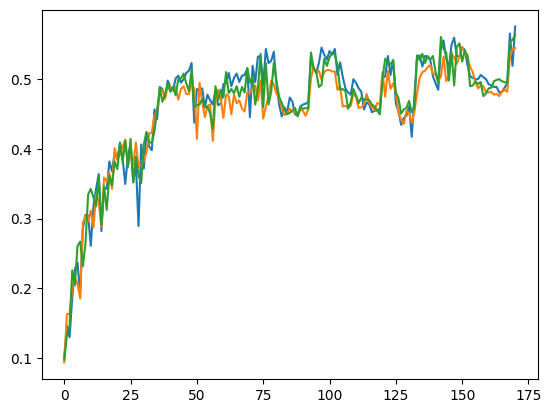

In [56]:
for i in range(3):
    plt.plot(tmp[i])

../logs/cifar10_group_notclip/alphaF-120sl-3cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_42/train/global
../logs/cifar10_group_notclip/alphaF-120sl-3cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_78/train/global
../logs/cifar10_group_notclip/alphaF-120sl-3cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_84/train/global
../logs/cifar10_group_notclip/alphaF-120sl-3cb-1ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_42/train/global
x
../logs/cifar10_group_notclip/alphaF-120sl-3cb-1ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_78/train/global
x
../logs/cifar10_group_notclip/alphaF-120sl-3cb-1ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/global
x


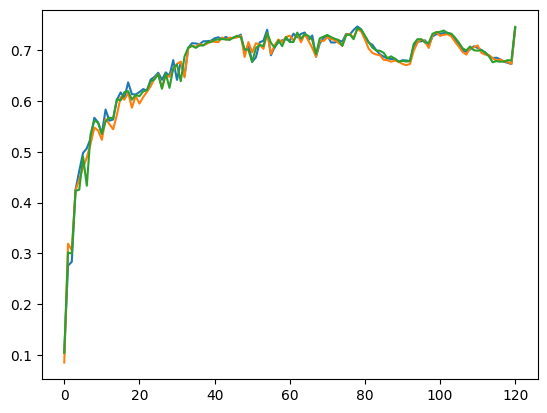

In [63]:
config1 = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="cifar10_group_notclip", seeds=["42", '78', '84'],
                          algorithms=["fedavg"], events=["global"],
                          lr_list=['1e-1','5e-2'], alphas=["0.5"], n_clients_list=["7"],
                          availabilities=['alphaF-120sl-3cb-1ft'],
                          n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")

tmp = get_exp_stats(config1)
tmp1 = tmp['test_accuracy'].values
for i in range(3):
    plt.plot(tmp1[i])

../logs/cifar10_group_notclip_v2/alphaF-120sl-3cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_42/train/global
../logs/cifar10_group_notclip_v2/alphaF-120sl-3cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_78/train/global
../logs/cifar10_group_notclip_v2/alphaF-120sl-3cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_84/train/global
../logs/cifar10_group_notclip_v2/alphaF-120sl-3cb-1ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_42/train/global
x
../logs/cifar10_group_notclip_v2/alphaF-120sl-3cb-1ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_78/train/global
x
../logs/cifar10_group_notclip_v2/alphaF-120sl-3cb-1ft/biased_2/fedavg/alpha_0.5/lr_5e-2/seed_84/train/global
x


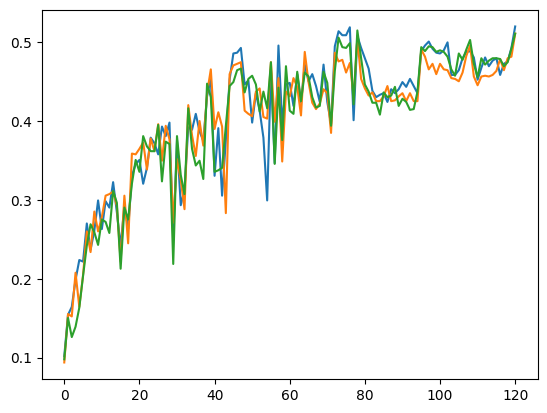

In [64]:
config1 = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="cifar10_group_notclip_v2", seeds=["42", '78', '84'],
                          algorithms=["fedavg"], events=["global"],
                          lr_list=['1e-1','5e-2'], alphas=["0.5"], n_clients_list=["7"],
                          availabilities=['alphaF-120sl-3cb-1ft'],
                          n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")

tmp = get_exp_stats(config1)
tmp1 = tmp['test_accuracy'].values
for i in range(3):
    plt.plot(tmp1[i])

In [18]:
def modify_data(_df):
    tmp = _df.groupby(['algorithm', 'availability','lr', 'alpha']).test_accuracy.apply(np.vstack).to_frame().reset_index()
    tmp['mean_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.mean(axis=0))
    tmp['var_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.var(axis=0))
    tmp['std_test_acc'] = tmp['test_accuracy'].apply(lambda x : x.std(axis=0))
    tmp['final_mean_acc'] = tmp['mean_test_acc'].apply(lambda x : x[-1])
    tmp['final_var_acc'] = tmp['var_test_acc'].apply(lambda x : x[-1])
    tmp['final_std_acc'] = tmp['std_test_acc'].apply(lambda x : x[-1])
    tmp['min_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.min(axis=0))
    tmp['max_test_acc'] = tmp['test_accuracy'].apply(lambda x: x.max(axis=0))
    return tmp

In [32]:
tmp = modify_data(results_df)
tmp = tmp.loc[tmp.groupby('availability')['final_mean_acc'].idxmax()]
fed_avg = tmp.loc[(tmp['algorithm'] == 'fedavg')]
fed_avg['slack_time'] = fed_avg['availability'].str.extract(r'-(\d+)sl')
fed_avg['ft'] = fed_avg['availability'].str.extract(r'-(\d+)ft').astype(int)

# Extract avail_mat
fed_avg['avail_mat'] = fed_avg['availability'].str.extract(r'-(\d+)cb')
fed_avg['slack_time'] = fed_avg['slack_time'].fillna(100).astype(int)
fed_avg['avail_mat'] = fed_avg['avail_mat'].fillna(0).astype(int)
fed_avg.sort_values('avail_mat', inplace=True)



In [33]:
fed_avg

,algorithm,availability,lr,alpha,test_accuracy,mean_test_acc,var_test_acc,std_test_acc,final_mean_acc,final_var_acc,final_std_acc,min_test_acc,max_test_acc,slack_time,ft,avail_mat
1,fedavg,alphaF-0cb-3ft,5e-2,0.5,"[[0.10589999705553055, 0.27559998631477356, 0....","[0.09813333302736282, 0.29866665601730347, 0.3...","[8.844222431925175e-05, 0.00031649560539352234...","[0.009404372616993211, 0.01779032336393924, 0....",0.750533,0.000005,0.002130,"[0.08489999920129776, 0.27559998631477356, 0.3...","[0.10589999705553055, 0.3188999891281128, 0.39...",100,3,0
2,fedavg,alphaF-100sl-1cb-1ft,5e-2,0.5,"[[0.10181451588869095, 0.14616934955120087, 0....","[0.0977822591861089, 0.14684139688809714, 0.18...","[1.0839402753161209e-05, 0.0001330084023884027...","[0.003292324824977209, 0.01153292687865499, 0....",0.529906,0.000247,0.015711,"[0.09375, 0.13306452333927155, 0.1673387140035...","[0.10181451588869095, 0.16129031777381897, 0.2...",100,1,1
3,fedavg,alphaF-100sl-1cb-3ft,5e-2,0.5,"[[0.10181451588869095, 0.15322580933570862, 0....","[0.0977822591861089, 0.14448924859364828, 0.18...","[1.0839402753161209e-05, 0.0001357184316636129...","[0.003292324824977209, 0.011649825391979615, 0...",0.536290,0.000090,0.009492,"[0.09375, 0.12802419066429138, 0.1713709682226...","[0.10181451588869095, 0.15322580933570862, 0.1...",100,3,1
10,fedavg,alphaF-110sl-1cb-1ft,5e-2,0.5,"[[0.10181451588869095, 0.14616934955120087, 0....","[0.0977822591861089, 0.14684139688809714, 0.18...","[1.0839402753161209e-05, 0.0001330084023884027...","[0.003292324824977209, 0.01153292687865499, 0....",0.529570,0.000047,0.006854,"[0.09375, 0.13306452333927155, 0.1673387140035...","[0.10181451588869095, 0.16129031777381897, 0.2...",110,1,1
11,fedavg,alphaF-110sl-1cb-3ft,5e-2,0.5,"[[0.10181451588869095, 0.14616934955120087, 0....","[0.0977822591861089, 0.14751343925793967, 0.17...","[1.0839402753161209e-05, 0.0001533322583495453...","[0.003292324824977209, 0.012382740340875492, 0...",0.533938,0.000077,0.008801,"[0.09375, 0.13306452333927155, 0.1683467775583...","[0.10181451588869095, 0.16330644488334656, 0.1...",110,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54,fedavg,alphaF-45sl-6cb-3ft,5e-2,0.5,"[[0.10181451588869095, 0.10080645233392715, 0....","[0.0977822591861089, 0.10416666666666667, 0.12...","[1.0839402753161209e-05, 0.0001384281688573901...","[0.003292324824977209, 0.011765550087326564, 0...",0.418011,0.000142,0.011937,"[0.09375, 0.09173387289047241, 0.1139112934470...","[0.10181451588869095, 0.11995967477560043, 0.1...",45,3,6
53,fedavg,alphaF-45sl-6cb-1ft,5e-2,0.5,"[[0.10181451588869095, 0.10080645233392715, 0....","[0.0977822591861089, 0.10416666666666667, 0.14...","[1.0839402753161209e-05, 0.0001384281688573901...","[0.003292324824977209, 0.011765550087326564, 0...",0.416331,0.000247,0.015703,"[0.09375, 0.09173387289047241, 0.1280241906642...","[0.10181451588869095, 0.11995967477560043, 0.1...",45,1,6
49,fedavg,alphaF-35sl-6cb-1ft,5e-2,0.5,"[[0.10181451588869095, 0.14516128599643707, 0....","[0.0977822591861089, 0.1612903227408727, 0.192...","[1.0839402753161209e-05, 0.0001470094486590609...","[0.003292324824977209, 0.012124745302853207, 0...",0.433468,0.000033,0.005762,"[0.09375, 0.14516128599643707, 0.1612903177738...","[0.10181451588869095, 0.17439515888690948, 0.2...",35,1,6
50,fedavg,alphaF-35sl-6cb-3ft,5e-2,0.5,"[[0.10181451588869095, 0.15927419066429138, 0....","[0.0977822591861089, 0.1582661271095276, 0.191...","[1.0839402753161209e-05, 0.0001429446500946044...","[0.003292324824977209, 0.011955946223306814, 0...",0.441868,0.000098,0.009923,"[0.09375, 0.14314515888690948, 0.15625, 0.1633...","[0.10181451588869095, 0.1723790317773819, 0.24...",35,3,6


# For 3ft

In [36]:
fed_avg_3ft = fed_avg.loc[(fed_avg["avail_mat"]!=7)&(fed_avg["ft"]==3)]

In [27]:
fed_avg_3ft.loc[fed_avg_3ft['avail_mat'] == 0, 'mean_test_acc']

Series([], Name: mean_test_acc, dtype: object)

In [38]:
alpha_test_acc = fed_avg_3ft['final_mean_acc'].values * 100
base_test_acc = fed_avg_3ft.loc[fed_avg_3ft['avail_mat'] == 0, 'mean_test_acc'].values[0].take([100,90,75,60,45,30,15]) *100 # 100,90,75,60,45,30,15,5
base_test_std_acc = fed_avg_3ft.loc[fed_avg_3ft['avail_mat'] == 0, 'std_test_acc'].values[0].take([100,90,75,60,45,30,15]) *100 

In [39]:
perc_cb_used = [100.0,86.03754606747044,
 64.34157007056174,
 48.57710810495588,
 36.59564700520919,
 25.653291413710384,
 12.555690542858041,
#  3.903694502135956
 ]

In [44]:
fed_avg_3ft

,algorithm,availability,lr,alpha,test_accuracy,mean_test_acc,var_test_acc,std_test_acc,final_mean_acc,final_var_acc,final_std_acc,min_test_acc,max_test_acc,slack_time,ft,avail_mat
1,fedavg,alphaF-0cb-3ft,5e-2,0.5,"[[0.10589999705553055, 0.27559998631477356, 0....","[0.09813333302736282, 0.29866665601730347, 0.3...","[8.844222431925175e-05, 0.00031649560539352234...","[0.009404372616993211, 0.01779032336393924, 0....",0.750533,4.535592e-06,0.002130,"[0.08489999920129776, 0.27559998631477356, 0.3...","[0.10589999705553055, 0.3188999891281128, 0.39...",100,3,0
3,fedavg,alphaF-100sl-1cb-3ft,5e-2,0.5,"[[0.10181451588869095, 0.15322580933570862, 0....","[0.0977822591861089, 0.14448924859364828, 0.18...","[1.0839402753161209e-05, 0.0001357184316636129...","[0.003292324824977209, 0.011649825391979615, 0...",0.536290,9.010245e-05,0.009492,"[0.09375, 0.12802419066429138, 0.1713709682226...","[0.10181451588869095, 0.15322580933570862, 0.1...",100,3,1
11,fedavg,alphaF-110sl-1cb-3ft,5e-2,0.5,"[[0.10181451588869095, 0.14616934955120087, 0....","[0.0977822591861089, 0.14751343925793967, 0.17...","[1.0839402753161209e-05, 0.0001533322583495453...","[0.003292324824977209, 0.012382740340875492, 0...",0.533938,7.745670e-05,0.008801,"[0.09375, 0.13306452333927155, 0.1683467775583...","[0.10181451588869095, 0.16330644488334656, 0.1...",110,3,1
26,fedavg,alphaF-130sl-1cb-3ft,5e-2,0.5,"[[0.10181451588869095, 0.14616934955120087, 0....","[0.0977822591861089, 0.14751343925793967, 0.17...","[1.0839402753161209e-05, 0.0001533322583495453...","[0.003292324824977209, 0.012382740340875492, 0...",0.540995,1.519775e-04,0.012328,"[0.09375, 0.13306452333927155, 0.1683467775583...","[0.10181451588869095, 0.16330644488334656, 0.1...",130,3,1
18,fedavg,alphaF-120sl-1cb-3ft,5e-2,0.5,"[[0.10181451588869095, 0.15322580933570862, 0....","[0.0977822591861089, 0.14448924859364828, 0.18...","[1.0839402753161209e-05, 0.0001357184316636129...","[0.003292324824977209, 0.011649825391979615, 0...",0.533266,1.978187e-04,0.014065,"[0.09375, 0.12802419066429138, 0.1713709682226...","[0.10181451588869095, 0.15322580933570862, 0.1...",120,3,1
30,fedavg,alphaF-140sl-1cb-3ft,5e-2,0.5,"[[0.10181451588869095, 0.15322580933570862, 0....","[0.0977822591861089, 0.14448924859364828, 0.18...","[1.0839402753161209e-05, 0.0001357184316636129...","[0.003292324824977209, 0.011649825391979615, 0...",0.556788,8.355424e-06,0.002891,"[0.09375, 0.12802419066429138, 0.1713709682226...","[0.10181451588869095, 0.15322580933570862, 0.1...",140,3,1
42,fedavg,alphaF-170sl-1cb-3ft,5e-2,0.5,"[[0.10181451588869095, 0.14616934955120087, 0....","[0.0977822591861089, 0.14751343925793967, 0.14...","[1.0839402753161209e-05, 0.0001533322583495453...","[0.003292324824977209, 0.012382740340875492, 0...",0.561156,1.655267e-04,0.012866,"[0.09375, 0.13306452333927155, 0.1300403177738...","[0.10181451588869095, 0.16330644488334656, 0.1...",170,3,1
36,fedavg,alphaF-150sl-1cb-3ft,5e-2,0.5,"[[0.10181451588869095, 0.14616934955120087, 0....","[0.0977822591861089, 0.14751343925793967, 0.17...","[1.0839402753161209e-05, 0.0001533322583495453...","[0.003292324824977209, 0.012382740340875492, 0...",0.555780,9.845773e-05,0.009923,"[0.09375, 0.13306452333927155, 0.1683467775583...","[0.10181451588869095, 0.16330644488334656, 0.1...",150,3,1
46,fedavg,alphaF-190sl-1cb-3ft,5e-2,0.5,"[[0.10181451588869095, 0.16834677755832672, 0....","[0.0977822591861089, 0.14986559251944223, 0.14...","[1.0839402753161209e-05, 0.0001790760026193617...","[0.003292324824977209, 0.013381928210066058, 0...",0.566868,3.010192e-04,0.017350,"[0.09375, 0.13709677755832672, 0.1219758093357...","[0.10181451588869095, 0.16834677755832672, 0.1...",190,3,1
28,fedavg,alphaF-135sl-2cb-3ft,5e-2,0.5,"[[0.10181451588869095, 0.16935484111309052, 0....","[0.0977822591861089, 0.15456989407539368, 0.15...","[1.0839402753161209e-05, 0.0001526549404663827...","[0.003292324824977209, 0.012355360798713357, 0...",0.534274,1.524288e-04,0.012346,"[0.09375, 0.1391129046678543,

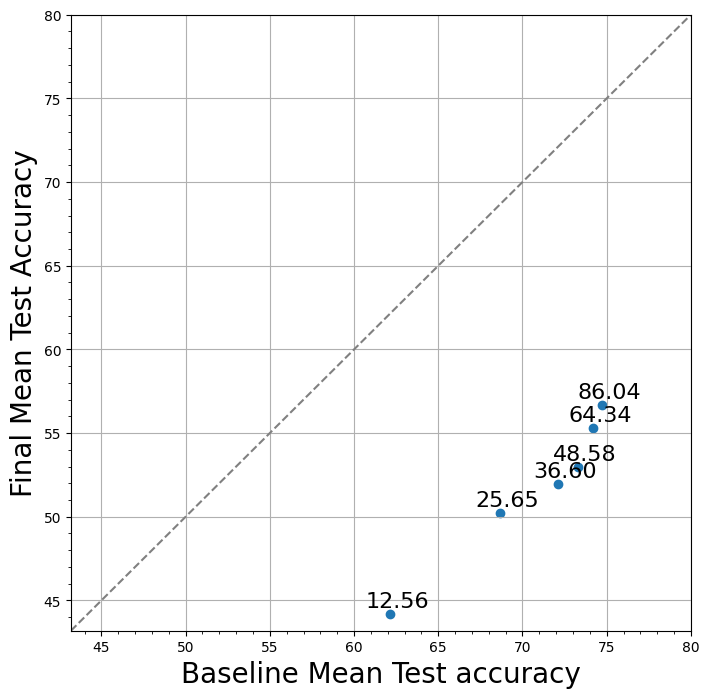

In [45]:
_tmp = fed_avg.loc[fed_avg.groupby('avail_mat')['final_mean_acc'].idxmax()]


plt.figure(figsize=(8,8))
plt.scatter(
    base_test_acc[1:],
    _tmp['final_mean_acc'].values[1:]*100,
    marker='o', 
)

for i, val in enumerate(_tmp[['final_mean_acc', 'slack_time']].values[1:]):
    plt.annotate(
        # f'{100 - 100*perc_cb_saved[i]:.2f}_{val[1]}',
        f'{perc_cb_used[i+1]:.2f}', 
        (base_test_acc[i+1],val[0]*100), 
        xytext=(5, 5), 
        textcoords="offset points", 
        ha='center', 
        fontsize=16
    )

x_min = min(min(base_test_acc[1:]), min(_tmp['final_mean_acc'].values[1:]*100))


plt.plot([x_min-1, 80.0], [x_min-1, 80.0], color='gray', linestyle='--')

plt.xlabel('Baseline Mean Test accuracy', fontsize=20)
plt.ylabel('Final Mean Test Accuracy', fontsize=20)
plt.grid(visible=True, which='major')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min-1, 80.0)
plt.ylim(x_min-1, 80.0)
# plt.title(f"Heterogeneity: {data_type}; fine_tuning_steps = 3, # rounds = 50")
# plt.savefig("../../50_0.5_1ft_slack.png")
plt.show()


In [11]:
df = fed_avg[['avail_mat', 'slack_time', 'final_mean_acc', 'final_std_acc']].sort_values(['avail_mat', 'slack_time']).__deepcopy__()
df["acc_str"] = df.apply(
    lambda r: f"{100*r.final_mean_acc:.2f} ({100*r.final_std_acc:.2f})",
    axis=1
)

# 2. Pivot table
df_wide = df.pivot(
    index="avail_mat",
    columns="slack_time",
    values="acc_str"
)

# 3. (Optional) sort columns numerically
df_wide = df_wide.sort_index(axis=1)

# 4. Reset index if you want avail_mat as a column
df_wide = df_wide.reset_index()

In [12]:
for acc,st in zip(base_test_acc[1:], base_test_std_acc[1:]):
    print(f"{acc:.2f} ({st:.2f})")

74.73 (0.21)
74.19 (0.17)
73.30 (0.18)
72.09 (0.11)
68.69 (0.51)
62.13 (0.40)


# For 1 ft

In [13]:
main_folder = 'cifar10_accuracy_check'
# ['1e-1', '1e-2', '1e-3', '1e-4', "5e-2"]

# availabilities="alphaF-0cb-3ft".split()
# availabilities="alphaF-0cb-3ft alphaF-120sl-1cb-3ft alphaF-120sl-2cb-3ft alphaF-120sl-3cb-3ft alphaF-120sl-4cb-3ft alphaF-120sl-5cb-3ft alphaF-120sl-6cb-3ft alphaF-140sl-1cb-3ft alphaF-140sl-2cb-3ft alphaF-140sl-3cb-3ft alphaF-140sl-4cb-3ft alphaF-140sl-5cb-3ft alphaF-140sl-6cb-3ft alphaF-160sl-1cb-3ft alphaF-160sl-2cb-3ft alphaF-160sl-3cb-3ft alphaF-160sl-4cb-3ft alphaF-160sl-5cb-3ft alphaF-160sl-6cb-3ft alphaF-180sl-1cb-3ft".split()
availabilities="alphaF-0cb-3ft alphaF-120sl-1cb-1ft alphaF-120sl-2cb-1ft alphaF-120sl-3cb-1ft alphaF-120sl-4cb-1ft alphaF-120sl-5cb-1ft alphaF-120sl-6cb-1ft alphaF-120sl-7cb-1ft alphaF-120sl-8cb-1ft alphaF-140sl-1cb-1ft alphaF-140sl-2cb-1ft alphaF-140sl-3cb-1ft alphaF-140sl-4cb-1ft alphaF-140sl-5cb-1ft alphaF-140sl-6cb-1ft alphaF-140sl-7cb-1ft alphaF-140sl-8cb-1ft alphaF-160sl-1cb-1ft alphaF-160sl-2cb-1ft alphaF-160sl-3cb-1ft alphaF-160sl-4cb-1ft alphaF-160sl-5cb-1ft alphaF-160sl-6cb-1ft alphaF-160sl-7cb-1ft alphaF-160sl-8cb-1ft alphaF-180sl-1cb-1ft alphaF-180sl-2cb-1ft alphaF-180sl-3cb-1ft alphaF-180sl-4cb-1ft alphaF-180sl-5cb-1ft alphaF-180sl-6cb-1ft alphaF-180sl-7cb-1ft alphaF-180sl-8cb-1ft alphaF-200sl-1cb-1ft alphaF-200sl-2cb-1ft alphaF-200sl-3cb-1ft alphaF-200sl-4cb-1ft alphaF-200sl-5cb-1ft alphaF-200sl-6cb-1ft alphaF-200sl-7cb-1ft alphaF-200sl-8cb-1ft".split() # list of availability matrices
# availabilities="alphaF-120sl-2cb-3ft alphaF-120sl-4cb-3ft alphaF-140sl-2cb-3ft alphaF-140sl-4cb-3ft alphaF-160sl-2cb-3ft alphaF-160sl-4cb-3ft alphaF-180sl-2cb-3ft alphaF-180sl-4cb-3ft alphaF-200sl-2cb-3ft alphaF-200sl-4cb-3ft".split() # list of availability matrices

main_folder = 'correlation_experiments_100rounds'
config = ExperimentConfig(base_path=os.path.join('..', 'logs'), experiment="cifar10_group_notclip", seeds=["42", '78', '84'],
                          algorithms=["fedavg"], events=["global"],
                          lr_list=['1e-1','5e-2'], alphas=["0.5"], n_clients_list=["7"],
                          availabilities=availabilities,
                          n_rounds="100", participations=["known"], biased_list=["2"], train_test="train")

results_df_1ft = get_exp_stats(config)


import ast

# Convert 'test_accuracy' column to lists if needed
results_df_1ft['test_accuracy'] = results_df_1ft['test_accuracy'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)


../logs/cifar10_group_notclip/alphaF-0cb-3ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_42/train/global
x
../logs/cifar10_group_notclip/alphaF-120sl-1cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_42/train/global
../logs/cifar10_group_notclip/alphaF-120sl-2cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_42/train/global
../logs/cifar10_group_notclip/alphaF-120sl-3cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_42/train/global
../logs/cifar10_group_notclip/alphaF-120sl-4cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_42/train/global
../logs/cifar10_group_notclip/alphaF-120sl-5cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_42/train/global
../logs/cifar10_group_notclip/alphaF-120sl-6cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_42/train/global
../logs/cifar10_group_notclip/alphaF-120sl-7cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_42/train/global
../logs/cifar10_group_notclip/alphaF-120sl-8cb-1ft/biased_2/fedavg/alpha_0.5/lr_1e-1/seed_42/train/global
../logs/cifar10_group_notclip/alphaF-140sl-1cb-1ft

In [14]:
tmp = modify_data(results_df_1ft)
tmp = tmp.loc[tmp.groupby('availability')['final_mean_acc'].idxmax()]
fed_avg_1ft = tmp.loc[(tmp['algorithm'] == 'fedavg')]
fed_avg_1ft['slack_time'] = fed_avg_1ft['availability'].str.extract(r'-(\d+)sl')

# Extract avail_mat
fed_avg_1ft['avail_mat'] = fed_avg_1ft['availability'].str.extract(r'-(\d+)cb')
fed_avg_1ft['slack_time'] = fed_avg_1ft['slack_time'].fillna(100).astype(int)
fed_avg_1ft['avail_mat'] = fed_avg_1ft['avail_mat'].fillna(0).astype(int)
fed_avg_1ft.sort_values('avail_mat', inplace=True)

In [15]:
fed_avg_1ft = fed_avg_1ft.loc[~fed_avg_1ft["avail_mat"].isin([7, 8])]

In [16]:
alpha_test_acc_1ft = fed_avg_1ft['final_mean_acc'].values * 100
base_test_acc_1ft = fed_avg_1ft.loc[fed_avg_1ft['avail_mat'] == 0, 'mean_test_acc'].values[0].take([100,90,75,60,45,30,15]) *100 # 100,90,75,60,45,30,15,5,3
base_test_std_acc_1ft = fed_avg_1ft.loc[fed_avg_1ft['avail_mat'] == 0, 'std_test_acc'].values[0].take([100,90,75,60,45,30,15]) *100 

In [17]:
perc_cb_used_1ft = [100.0,86.03754606747044,
 64.34157007056174,
 48.57710810495588,
 36.59564700520919,
 25.653291413710384,
 12.555690542858041,
#  3.903694502135956,
#  2.3083573977423577
 ]

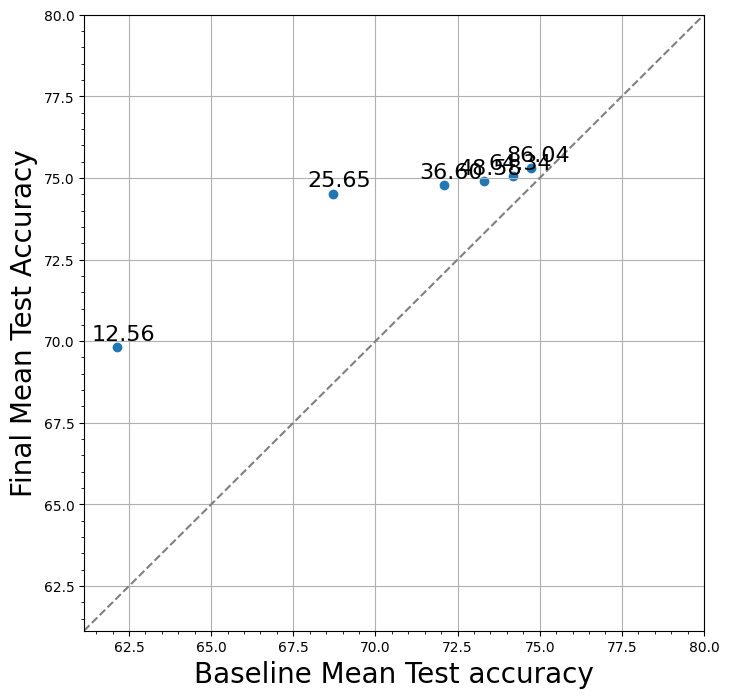

In [18]:
_tmp_1ft = fed_avg_1ft.loc[fed_avg_1ft.groupby('avail_mat')['final_mean_acc'].idxmax()]


plt.figure(figsize=(8,8))
plt.scatter(
    base_test_acc_1ft[1:],
    _tmp_1ft['final_mean_acc'].values[1:]*100,
    marker='o', 
)

for i, val in enumerate(_tmp_1ft[['final_mean_acc', 'slack_time']].values[1:]):
    plt.annotate(
        # f'{100 - 100*perc_cb_saved[i]:.2f}_{val[1]}',
        f'{perc_cb_used_1ft[i+1]:.2f}', 
        (base_test_acc_1ft[i+1],val[0]*100), 
        xytext=(5, 5), 
        textcoords="offset points", 
        ha='center', 
        fontsize=16
    )

x_min = min(min(base_test_acc_1ft[1:]), min(_tmp_1ft['final_mean_acc'].values[1:]*100))


plt.plot([x_min-1, 80.0], [x_min-1, 80.0], color='gray', linestyle='--')

plt.xlabel('Baseline Mean Test accuracy', fontsize=20)
plt.ylabel('Final Mean Test Accuracy', fontsize=20)
plt.grid(visible=True, which='major')
plt.minorticks_on()

# Set equal x and y limits
plt.xlim(x_min-1, 80.0)
plt.ylim(x_min-1, 80.0)
# plt.title(f"Heterogeneity: {data_type}; fine_tuning_steps = 3, # rounds = 50")
# plt.savefig("../../50_0.5_1ft_slack.png")
plt.show()


In [19]:
df = fed_avg_1ft[['avail_mat', 'slack_time', 'final_mean_acc', 'final_std_acc']].sort_values(['avail_mat', 'slack_time']).__deepcopy__()
df["acc_str"] = df.apply(
    lambda r: f"{100*r.final_mean_acc:.2f} ({100*r.final_std_acc:.2f})",
    axis=1
)

# 2. Pivot table
df_wide = df.pivot(
    index="avail_mat",
    columns="slack_time",
    values="acc_str"
)

# 3. (Optional) sort columns numerically
df_wide = df_wide.sort_index(axis=1)

# 4. Reset index if you want avail_mat as a column
df_wide = df_wide.reset_index()

In [20]:
df_wide

slack_time,avail_mat,100,120,140,160,180,200
0,0,75.05 (0.21),NaN,NaN,NaN,NaN,NaN
1,1,NaN,74.58 (0.01),74.76 (0.11),74.84 (0.15),74.93 (0.04),75.29 (0.23)
2,2,NaN,74.22 (0.13),74.76 (0.14),74.52 (0.35),74.95 (0.28),75.05 (0.06)
3,3,NaN,74.50 (0.11),74.75 (0.20),74.90 (0.16),74.84 (0.13),74.82 (0.13)
4,4,NaN,74.17 (0.12),74.38 (0.32),74.55 (0.36),74.45 (0.04),74.78 (0.57)
5,5,NaN,74.38 (0.12),74.43 (0.41),74.52 (0.53),73.85 (0.44),73.58 (0.08)
6,6,NaN,68.50 (0.61),69.82 (0.52),67.84 (0.52),66.53 (0.90),66.08 (0.56)


In [21]:
for acc,st in zip(base_test_acc[1:], base_test_std_acc[1:]):
    print(f"{acc:.2f} ({st:.2f})")

74.73 (0.21)
74.19 (0.17)
73.30 (0.18)
72.09 (0.11)
68.69 (0.51)
62.13 (0.40)


# PLOTS

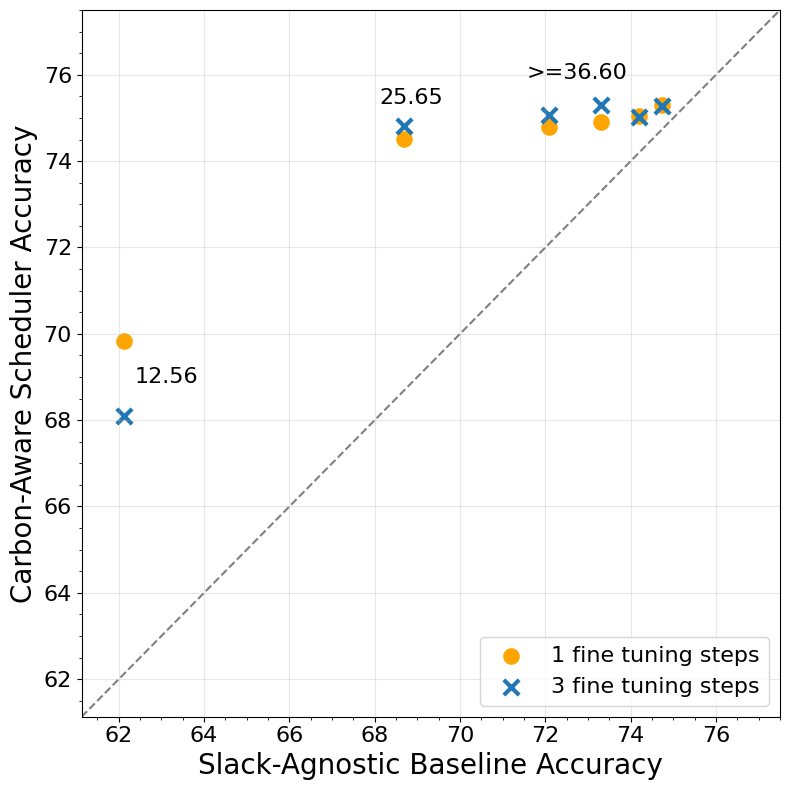

In [63]:
plt.figure(figsize=(8,8))
plt.scatter(
    base_test_acc_1ft[1:],
    _tmp_1ft['final_mean_acc'].values[1:]*100,
    marker='o',
    s=120,
    color='orange',
    label='1 fine tuning steps'
)

plt.scatter(
    base_test_acc[1:],
    _tmp['final_mean_acc'].values[1:]*100,
    marker='x',
    s=120,
    linewidths=3,
    color='tab:blue',
    label='3 fine tuning steps'
)

# Annotations
for i, val in enumerate(_tmp_1ft[['final_mean_acc', 'slack_time']].values[1:]):
    if perc_cb_used_1ft[i+1] ==perc_cb_used_1ft[-2]:
        plt.annotate(
            # f'{100 - 100*perc_cb_saved[i]:.2f}_{val[1]}',
            f'{perc_cb_used_1ft[i+1]:.2f}', 
            (base_test_acc_1ft[i+1],val[0]*100), 
            xytext=(5, 25), 
            textcoords="offset points", 
            ha='center', 
            fontsize=16
        )
    elif perc_cb_used_1ft[i+1] ==perc_cb_used_1ft[-1]:
        plt.annotate(
            # f'{100 - 100*perc_cb_saved[i]:.2f}_{val[1]}',
            f'{perc_cb_used_1ft[i+1]:.2f}', 
            (base_test_acc_1ft[i+1],val[0]*100), 
            xytext=(30, -30), 
            textcoords="offset points", 
            ha='center', 
            fontsize=16
        )
    elif perc_cb_used_1ft[i+1]==perc_cb_used_1ft[-3]:
        plt.annotate(
            # f'{100 - 100*perc_cb_saved[i]:.2f}_{val[1]}',
            f'>={perc_cb_used_1ft[i+1]:.2f}', 
            (base_test_acc_1ft[i+1],val[0]*100), 
            xytext=(20, 35), 
            textcoords="offset points", 
            ha='center', 
            fontsize=16
        )
        flg=1

x_min = min(min(base_test_acc_1ft[1:]), min(_tmp_1ft['final_mean_acc'].values[1:]*100))


plt.plot([x_min-1, 77.5], [x_min-1, 77.5], color='gray', linestyle='--')

plt.xlabel('Slack-Agnostic Baseline Accuracy', fontsize=20)
plt.ylabel('Carbon-Aware Scheduler Accuracy', fontsize=20)
# plt.xticks([60, 65, 70, 75, 80])
# plt.yticks([60, 65, 70, 75, 80])
plt.tick_params(axis='both', which='major', labelsize=16)
plt.grid(True, which='major', alpha=0.3)
plt.minorticks_on()
plt.legend(fontsize=16, loc='lower right')


# Set equal x and y limits
plt.xlim(x_min-1, 77.5)
plt.ylim(x_min-1, 77.5)
# plt.title(f"Heterogeneity: {data_type}; fine_tuning_steps = 3, # rounds = 50")
plt.savefig("../../cifar10_final_plt.png")

plt.tight_layout()
plt.show()
